In [ ]:
#@title Preparação de Dependências

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, HashingVectorizer
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import Normalizer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score, classification_report
from sklearn.base import BaseEstimator, TransformerMixin
import re
import string

from imblearn.over_sampling import SMOTE
from collections import Counter

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."



Distribuição de classes (Dataset Completo):
label
ham     4825
spam     747
Name: count, dtype: int64

Distribuição de classes ANTES do SMOTE (70/30 Split - Treino):

label
ham     3372
spam     528
Name: count, dtype: int64




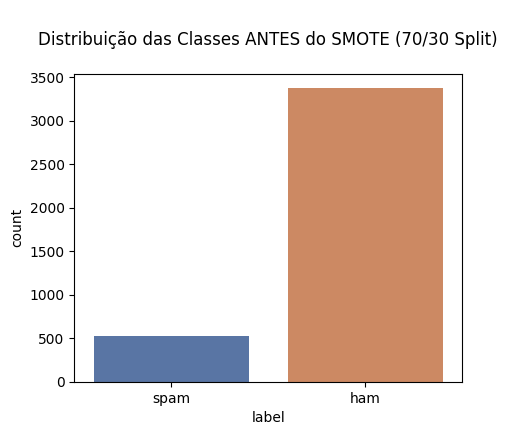


Distribuição de classes APÓS o SMOTE (Treino):

label
spam    3372
ham     3372
Name: count, dtype: int64




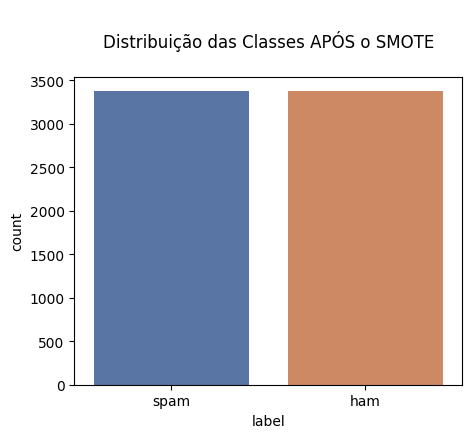

In [ ]:
#@title Seção 001: Preparação de Dados

path = kagglehub.dataset_download("uciml/sms-spam-collection-dataset")

df = pd.read_csv(path + '/spam.csv', encoding='latin-1')
df = df[['v1','v2']]
df.columns = ['label','message']

display(df.head(5))

print("\nDistribuição de classes (Dataset Completo):")
print(df['label'].value_counts())

y_train_70_series = pd.Series(y_train_70, name='label')

print("\nDistribuição de classes ANTES do SMOTE (70/30 Split - Treino):\n")
print(y_train_70_series.value_counts())
print("\n")

plt.figure(figsize=(5,4))
sns.countplot(x=y_train_70_series, palette='deep')
plt.title("\nDistribuição das Classes ANTES do SMOTE (70/30 Split)\n")
plt.show()

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_vc_train_70, y_train_70)

y_train_smote_series = pd.Series(y_train_smote, name='label')

print("\nDistribuição de classes APÓS o SMOTE (Treino):\n")
print(y_train_smote_series.value_counts())
print("\n")

plt.figure(figsize=(5,4))
sns.countplot(x=y_train_smote_series, palette='deep')
plt.title("\nDistribuição das Classes APÓS o SMOTE\n")
plt.show()


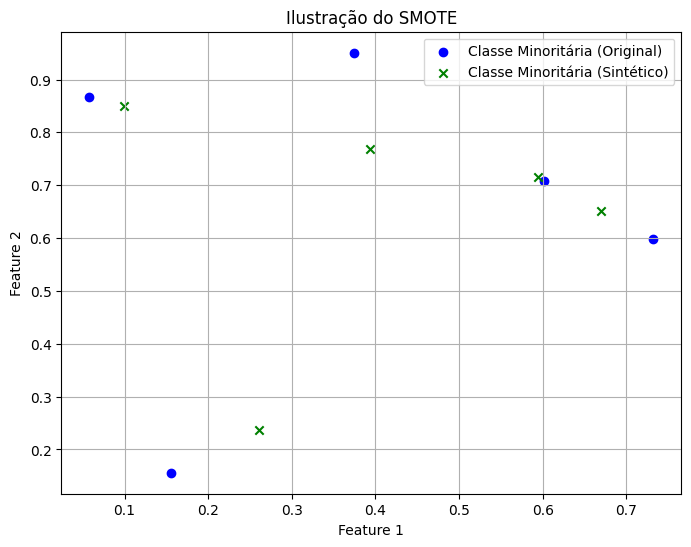

In [ ]:
#@title Ilustração do Funcionamento do SMOTE

np.random.seed(42)
minority_points = np.random.rand(5, 2)
synthetic_points = []

for point in minority_points:
    neighbor = minority_points[np.random.randint(0, len(minority_points))]
    random_factor = np.random.rand()
    synthetic_point = point + random_factor * (neighbor - point)
    synthetic_points.append(synthetic_point)

synthetic_points = np.array(synthetic_points)

plt.figure(figsize=(8, 6))
plt.scatter(minority_points[:, 0], minority_points[:, 1], color='blue', label='Classe Minoritária (Original)')
plt.scatter(synthetic_points[:, 0], synthetic_points[:, 1], color='green', marker='x', label='Classe Minoritária (Sintético)')
plt.title("Ilustração do SMOTE")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
#@title Pré-Processamento do Texto

def basic_preprocessing(text):
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['cleaned_message'] = df['message'].apply(basic_preprocessing)

print("\n[A]ntes e [D]epois do pré-processamento:\n")
for i in [0,1,2]:
    print("A:", df['message'].iloc[i])
    print("D:", df['cleaned_message'].iloc[i])
    print("\n---------------------------------------------------------------------------------------------------------\n")



[A]ntes e [D]epois do pré-processamento:

A: Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
D: go until jurong point crazy available only in bugis n great world la e buffet cine there got amore wat

---------------------------------------------------------------------------------------------------------

A: Ok lar... Joking wif u oni...
D: ok lar joking wif u oni

---------------------------------------------------------------------------------------------------------

A: Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
D: free entry in 2 a wkly comp to win fa cup final tkts 21st may 2005 text fa to 87121 to receive entry questionstd txt ratetcs apply 08452810075over18s

---------------------------------------------------------------------------------------------------------



In [ ]:
#@title Seção 003: Vetorização dos Dados

y = df['label'].values

count_vec = CountVectorizer()
tfidf_vec = TfidfVectorizer()
hash_vec = HashingVectorizer(n_features=1024, norm=None, alternate_sign=False)

X_vc = count_vec.fit_transform(df['cleaned_message'])
X_tfidf = tfidf_vec.fit_transform(df['cleaned_message'])
X_hash = hash_vec.transform(df['cleaned_message'])
normalizer = Normalizer(norm='l1')
X_l1 = normalizer.fit_transform(X_hash)


In [ ]:
#@title Seção 004: Divisão em Treino e Teste


# 70/30
X_vc_train_70, X_vc_test_30, y_train_70, y_test_30 = train_test_split(X_vc, y, test_size=0.3, random_state=42)
X_tfidf_train_70, X_tfidf_test_30, y_train_70, y_test_30 = train_test_split(X_tfidf, y, test_size=0.3, random_state=42)
X_l1_train_70, X_l1_test_30, y_train_70, y_test_30 = train_test_split(X_l1, y, test_size=0.3, random_state=42)

# 80/20
X_vc_train_80, X_vc_test_20, y_train_80, y_test_20 = train_test_split(X_vc, y, test_size=0.2, random_state=42)
X_tfidf_train_80, X_tfidf_test_20, y_train_80, y_test_20 = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)
X_l1_train_80, X_l1_test_20, y_train_80, y_test_20 = train_test_split(X_l1, y, test_size=0.2, random_state=42)


In [ ]:
#@title Seção 005: Treinamento dos Modelos

models = {
    'MultinomialNB': MultinomialNB(),
    'GaussianNB': GaussianNB()
}

vectorizations = {
    'Count': (X_vc_train_70, X_vc_test_30, X_vc_train_80, X_vc_test_20),
    'TFIDF': (X_tfidf_train_70, X_tfidf_test_30, X_tfidf_train_80, X_tfidf_test_20),
    'HashL1': (X_l1_train_70, X_l1_test_30, X_l1_train_80, X_l1_test_20)
}

results = []

for model_name, model in models.items():
    for vec_name, (X_train_70, X_test_30, X_train_80, X_test_20) in vectorizations.items():

        if model_name == 'GaussianNB':
            X_train_70_dense = X_train_70.toarray() if hasattr(X_train_70, 'toarray') else X_train_70
            X_test_30_dense = X_test_30.toarray() if hasattr(X_test_30, 'toarray') else X_test_30
            X_train_80_dense = X_train_80.toarray() if hasattr(X_train_80, 'toarray') else X_train_80
            X_test_20_dense = X_test_20.toarray() if hasattr(X_test_20, 'toarray') else X_test_20
        else:
            X_train_70_dense = X_train_70
            X_test_30_dense = X_test_30
            X_train_80_dense = X_train_80
            X_test_20_dense = X_test_20

        # 70/30
        model.fit(X_train_70_dense, y_train_70)
        y_pred_30 = model.predict(X_test_30_dense)
        acc_30 = accuracy_score(y_test_30, y_pred_30)
        f1_30 = f1_score(y_test_30, y_pred_30, pos_label='spam')

        results.append({
            'Model': model_name,
            'Vectorization': vec_name,
            'Train/Test Split': '70/30',
            'SMOTE': 'No',
            'Accuracy': acc_30,
            'F1': f1_30,
            'Predictions': (y_test_30, y_pred_30)
        })

        # 80/20
        model.fit(X_train_80_dense, y_train_80)
        y_pred_20 = model.predict(X_test_20_dense)
        acc_20 = accuracy_score(y_test_20, y_pred_20)
        f1_20 = f1_score(y_test_20, y_pred_20, pos_label='spam')

        results.append({
            'Model': model_name,
            'Vectorization': vec_name,
            'Train/Test Split': '80/20',
            'SMOTE': 'No',
            'Accuracy': acc_20,
            'F1': f1_20,
            'Predictions': (y_test_20, y_pred_20)
        })


In [ ]:
#@title Resultados: Sem SMOTE
results_df = pd.DataFrame(results)

display(results_df[['Model','Vectorization','Train/Test Split','SMOTE','Accuracy','F1']])


,Model,Vectorization,Train/Test Split,SMOTE,Accuracy,F1
0,MultinomialNB,Count,70/30,No,0.979067,0.919908
1,MultinomialNB,Count,80/20,No,0.978475,0.920000
2,MultinomialNB,TFIDF,70/30,No,0.947967,0.752137
3,MultinomialNB,TFIDF,80/20,No,0.956951,0.809524
4,MultinomialNB,HashL1,70/30,No,0.869019,0.000000
5,MultinomialNB,HashL1,80/20,No,0.865471,0.000000
6,GaussianNB,Count,70/30,No,0.900718,0.706714
7,GaussianNB,Count,80/20,No,0.893274,0.697201
8,GaussianNB,TFIDF,70/30,No,0.899522,0.701068
9,GaussianNB,TFIDF,80/20,No,0.890583,0.687179


In [ ]:
#@title Seção 006: Aplicando SMOTE para o top-4 cenários

scenarios = [
    ('MultinomialNB', 'Count', '70/30', X_vc_train_70, X_vc_test_30, y_train_70, y_test_30),
    ('MultinomialNB', 'Count', '80/20', X_vc_train_80, X_vc_test_20, y_train_80, y_test_20),
    ('MultinomialNB', 'TFIDF', '70/30', X_tfidf_train_70, X_tfidf_test_30, y_train_70, y_test_30),
    ('MultinomialNB', 'TFIDF', '80/20', X_tfidf_train_80, X_tfidf_test_20, y_train_80, y_test_20),
]

for (model_name, vec_name, split, X_train, X_test, y_train, y_test) in scenarios:
    X_train_dense = X_train.toarray() if hasattr(X_train, 'toarray') else X_train
    X_test_dense = X_test.toarray() if hasattr(X_test, 'toarray') else X_test

    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train_dense, y_train)

    model_smote = MultinomialNB()
    model_smote.fit(X_train_smote, y_train_smote)
    y_pred_smote = model_smote.predict(X_test_dense)

    acc_smote = accuracy_score(y_test, y_pred_smote)
    f1_smote = f1_score(y_test, y_pred_smote, pos_label='spam')

    new_row = pd.DataFrame([{
        'Model': model_name,
        'Vectorization': vec_name,
        'Train/Test Split': split,
        'SMOTE': 'Yes',
        'Accuracy': acc_smote,
        'F1': f1_smote,
        'Predictions': (y_test, y_pred_smote)
    }])
    results_df = pd.concat([results_df, new_row], ignore_index=True)

print("Comparação SEM e COM SMOTE (MultinomialNB, Count/TFIDF, 70/30 e 80/20):")
comp = results_df[
    (results_df['Model']=='MultinomialNB') &
    (results_df['Vectorization'].isin(['Count','TFIDF'])) &
    (results_df['Train/Test Split'].isin(['70/30','80/20']))
][['Model','Vectorization','Train/Test Split','SMOTE','Accuracy','F1']]

display(comp.sort_values(by=['Vectorization','Train/Test Split','SMOTE']))


Comparação SEM e COM SMOTE (MultinomialNB, Count/TFIDF, 70/30 e 80/20):


,Model,Vectorization,Train/Test Split,SMOTE,Accuracy,F1
0,MultinomialNB,Count,70/30,No,0.979067,0.919908
12,MultinomialNB,Count,70/30,Yes,0.973684,0.898148
1,MultinomialNB,Count,80/20,No,0.978475,0.920000
13,MultinomialNB,Count,80/20,Yes,0.977578,0.915254
2,MultinomialNB,TFIDF,70/30,No,0.947967,0.752137
14,MultinomialNB,TFIDF,70/30,Yes,0.976077,0.907834
3,MultinomialNB,TFIDF,80/20,No,0.956951,0.809524
15,MultinomialNB,TFIDF,80/20,Yes,0.974888,0.907285



Melhor cenário SEM SMOTE: MultinomialNB, Count, 80/20
Acurácia: 0.9785, F1: 0.9200



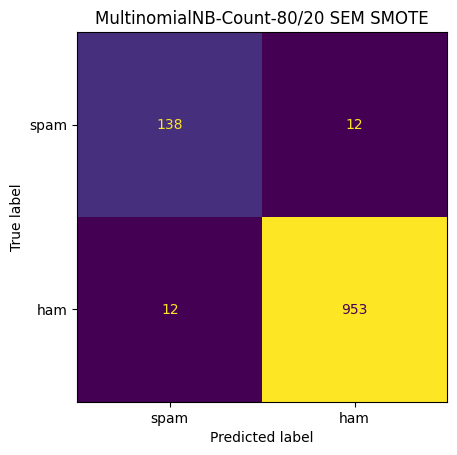


Classification Report MultinomialNB-Count-80/20 SEM SMOTE:
              precision    recall  f1-score   support

        spam       0.99      0.99      0.99       965
         ham       0.92      0.92      0.92       150

    accuracy                           0.98      1115
   macro avg       0.95      0.95      0.95      1115
weighted avg       0.98      0.98      0.98      1115


Mesmo cenário COM SMOTE:
Acurácia: 0.9776, F1: 0.9153



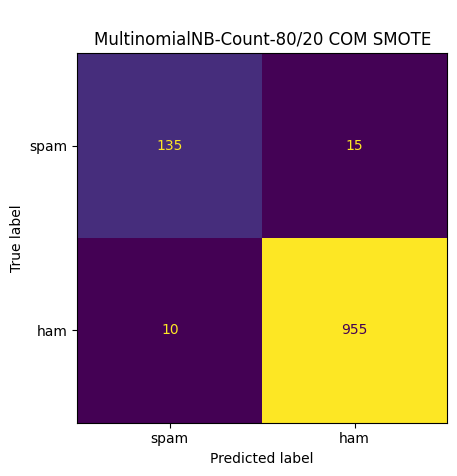


Classification Report MultinomialNB-Count-80/20 COM SMOTE:
              precision    recall  f1-score   support

        spam       0.98      0.99      0.99       965
         ham       0.93      0.90      0.92       150

    accuracy                           0.98      1115
   macro avg       0.96      0.94      0.95      1115
weighted avg       0.98      0.98      0.98      1115



In [ ]:
#@title Resultados: Matrizes de Confusão SEM vs COM SMOTE (Melhor Cenário)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

no_smote_scenarios = results_df[results_df['SMOTE'] == 'No']

best_no_smote = no_smote_scenarios.sort_values('F1', ascending=False).iloc[0]

model_name = best_no_smote['Model']
vec_name = best_no_smote['Vectorization']
split = best_no_smote['Train/Test Split']

print(f"\nMelhor cenário SEM SMOTE: {model_name}, {vec_name}, {split}")
print(f"Acurácia: {best_no_smote['Accuracy']:.4f}, F1: {best_no_smote['F1']:.4f}\n")

y_test_no, y_pred_no = best_no_smote['Predictions']

cm_no = confusion_matrix(y_test_no, y_pred_no, labels=['spam','ham'])
disp_no = ConfusionMatrixDisplay(cm_no, display_labels=['spam','ham'])
disp_no.plot(colorbar=False)
plt.title(f"{model_name}-{vec_name}-{split} SEM SMOTE")
plt.show()

print(f"\nClassification Report {model_name}-{vec_name}-{split} SEM SMOTE:")
print(classification_report(y_test_no, y_pred_no, target_names=['spam','ham']))

same_scenario_smote = results_df[(results_df['Model'] == model_name) &
                                 (results_df['Vectorization'] == vec_name) &
                                 (results_df['Train/Test Split'] == split) &
                                 (results_df['SMOTE'] == 'Yes')]

if len(same_scenario_smote) > 0:
    best_smote = same_scenario_smote.iloc[0]
    print("\nMesmo cenário COM SMOTE:")
    print(f"Acurácia: {best_smote['Accuracy']:.4f}, F1: {best_smote['F1']:.4f}\n")

    y_test_sm, y_pred_sm = best_smote['Predictions']

    cm_sm = confusion_matrix(y_test_sm, y_pred_sm, labels=['spam','ham'])
    disp_sm = ConfusionMatrixDisplay(cm_sm, display_labels=['spam','ham'])
    disp_sm.plot(colorbar=False)
    plt.title(f"\n{model_name}-{vec_name}-{split} COM SMOTE")
    plt.show()

    print(f"\nClassification Report {model_name}-{vec_name}-{split} COM SMOTE:")
    print(classification_report(y_test_sm, y_pred_sm, target_names=['spam','ham']))
else:
    print("\nN/A")


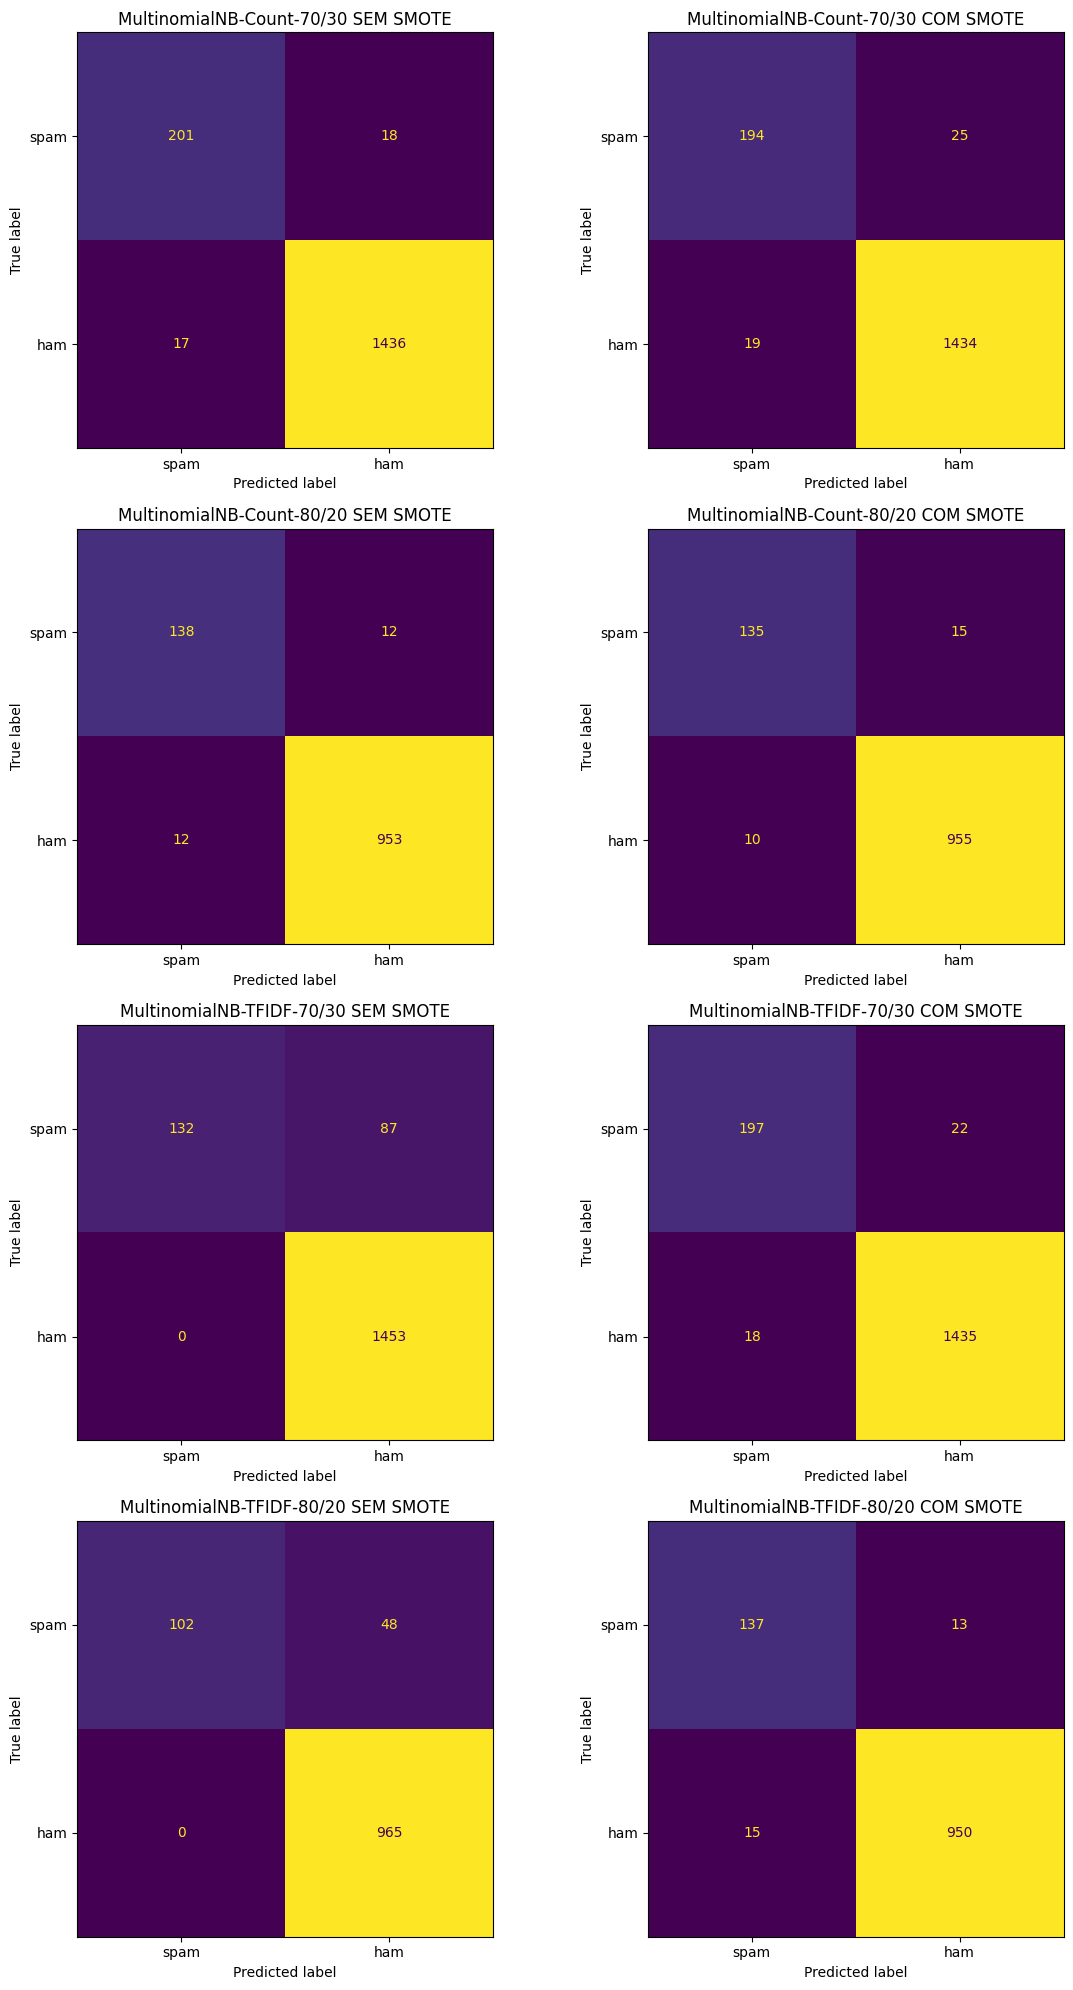

In [ ]:
#@title Resultados: Matrizes de Confusão SEM vs COM SMOTE

fig, axes = plt.subplots(4, 2, figsize=(12,20))
axes = axes.flatten()

scenarios_to_plot = [
    ('MultinomialNB', 'Count', '70/30'),
    ('MultinomialNB', 'Count', '80/20'),
    ('MultinomialNB', 'TFIDF', '70/30'),
    ('MultinomialNB', 'TFIDF', '80/20'),
]

i = 0
for (model_name, vec_name, split) in scenarios_to_plot:
    scenario_no_smote = results_df[(results_df['Model']==model_name) &
                                   (results_df['Vectorization']==vec_name) &
                                   (results_df['Train/Test Split']==split) &
                                   (results_df['SMOTE']=='No')].iloc[0]
    y_test_no, y_pred_no = scenario_no_smote['Predictions']

    scenario_smote = results_df[(results_df['Model']==model_name) &
                                (results_df['Vectorization']==vec_name) &
                                (results_df['Train/Test Split']==split) &
                                (results_df['SMOTE']=='Yes')].iloc[0]
    y_test_sm, y_pred_sm = scenario_smote['Predictions']

    cm_no = confusion_matrix(y_test_no, y_pred_no, labels=['spam','ham'])
    disp_no = ConfusionMatrixDisplay(cm_no, display_labels=['spam','ham'])
    disp_no.plot(ax=axes[i], colorbar=False)
    axes[i].set_title(f"{model_name}-{vec_name}-{split} SEM SMOTE")

    cm_sm = confusion_matrix(y_test_sm, y_pred_sm, labels=['spam','ham'])
    disp_sm = ConfusionMatrixDisplay(cm_sm, display_labels=['spam','ham'])
    disp_sm.plot(ax=axes[i+1], colorbar=False)
    axes[i+1].set_title(f"{model_name}-{vec_name}-{split} COM SMOTE")

    i += 2

plt.tight_layout()
plt.show()
